# CARMA: Aluminum Coagulation

The Community Aerosol and Radiation Model for Atmospheres, [CARMA](https://github.com/ESCOMP/CARMA), can be configured and run through musica. This tutorial configures a coagulation test for aluminum particles in 5 size bins. The [CARMA sulfate tutorial](8.%20carma_sulfate.ipynb) shows a more complex configuration with gases, growth, and nucleation.

All input data to the musica CARMA package must be in SI units. For example, use meters, not centimeters, and pascals, not hectopascals. When CARMA expects a different unit, musica does the conversion.

CARMA applies the processes in a fixed order in each time step. The order in which you add the processes to `CARMAParameters` has no effect. In each step, CARMA does these operations:

1. Vertical transport, when `initialization.do_vtran` is `True`.
2. Coagulation.
3. Nucleation, growth, and evaporation.

First, we import the packages.

In [1]:
import musica
import ussa1976
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

## Configure CARMA

Next, we create a group, an element, and a coagulation process. Each group, element, solute, and gas has a unique `short_name`. Other configurations refer to it by this name. Here, the element and the coagulation process refer to the group `"PRALUM"`.

The `CARMAParameters` object holds the configuration. We use it to create an instance of CARMA.

In [2]:
group = musica.carma.CARMAGroupConfig(
    short_name="PRALUM",
    name="aluminum",
    rmrat=2.0,
    rmin=21.5e-6,
    rmon=21.5e-6,
    ishape=musica.carma.ParticleShape.SPHERE,
    eshape=1.0,
    mie_calculation_algorithm=musica.carma.MieCalculationAlgorithm.TOON_1981,
    is_ice=False,
    is_fractal=True,
    do_wetdep=False,
    do_drydep=True,
    do_vtran=True,
    solfac=0.0,
    scavcoef=0.0,
    df=[1.6] * 5,
    falpha=1.0
)

element = musica.carma.CARMAElementConfig(
    short_name="ALUM",
    group="PRALUM",
    name="Aluminum",
    itype=musica.carma.ParticleType.INVOLATILE,
    icomposition=musica.carma.ParticleComposition.ALUMINUM,
    rho=0.00395,
    arat=[1.0] * 5,
    kappa=0.0,
)

coagulation = musica.carma.CARMACoagulationConfig(
    group1="PRALUM",
    group2="PRALUM",
    group3="PRALUM",
    algorithm=musica.carma.ParticleCollectionAlgorithm.FUCHS)

params = musica.carma.CARMAParameters(
    nbin=5,
    groups=[group],
    elements=[element],
    coagulations=[coagulation]
)
params.initialization.do_vtran = False

carma = musica.carma.CARMA(params)

## Set the environmental conditions

Next, we make the environmental data for the state. The vertical grid is not part of the CARMA parameters. The length of `vertical_center` sets the number of vertical levels when we create the state.

In [3]:
n_levels = 1
deltaz = 1000.0
zmin = 16500.0

vertical_center = zmin + (np.arange(n_levels) + 0.5) * deltaz
vertical_levels = zmin + np.arange(n_levels + 1) * deltaz

centered_variables = ussa1976.compute(z=vertical_center, variables=["t", "p", "rho"])
edge_variables = ussa1976.compute(z=vertical_levels, variables=["p"])

temperature = centered_variables.t.values
pressure = centered_variables.p.values
pressure_levels = edge_variables.p.values
density = centered_variables.rho.values

## Run the box model

Now we run the box model for five days. The `time_step` argument of `create_state()` sets the time step. While the model runs, we collect the data. At the end, we combine all of the data into one xarray dataset.

In [4]:
dtime = 1800.0
FIVE_DAYS_IN_SECONDS = 432000
nstep = int(FIVE_DAYS_IN_SECONDS // dtime)

mmr_initial = 5e9 / (deltaz * 2.57474699e14) / density[0]

state = carma.create_state(
    time_step=dtime,
    temperature=temperature,
    pressure=pressure,
    pressure_levels=pressure_levels,
    vertical_center=vertical_center,
    vertical_levels=vertical_levels,
    longitude=0.0,
    latitude=-105.0,
    coordinates=musica.carma.CarmaCoordinates.CARTESIAN,
)

for i in range(params.nbin):
    state.set_bin(i + 1, "ALUM", mmr_initial)

bin_data = state.get_bins().expand_dims({"time": [0.0]})
env = state.get_environmental_values().expand_dims({"time": [0.0]})

for step in range(1, nstep):
    state.step()
    bin_data = xr.concat([bin_data, state.get_bins().expand_dims({"time": [step * dtime]})], dim="time")
    env = xr.concat([env, state.get_environmental_values().expand_dims({"time": [step * dtime]})], dim="time")

ds = xr.merge([bin_data, env])

In [5]:
ds

<xarray.Dataset> Size: 154kB
Dimensions:                     (time: 240, bin: 5, element: 1,
                                 vertical_center: 1, vertical_level: 2)
Coordinates:
  * time                        (time) float64 2kB 0.0 1.8e+03 ... 4.302e+05
  * bin                         (bin) int64 40B 1 2 3 4 5
  * element                     (element) <U4 16B 'ALUM'
  * vertical_center             (vertical_center) float64 8B 1.7e+04
  * vertical_level              (vertical_level) float64 16B 1.65e+04 1.75e+04
Data variables: (12/18)
    mass_mixing_ratio           (time, bin, element, vertical_center) float64 10kB ...
    number_mixing_ratio         (time, bin, element, vertical_center) float64 10kB ...
    number_density              (time, bin, element, vertical_center) float64 10kB ...
    nucleation_rate             (time, bin, element, vertical_center) float64 10kB ...
    wet_particle_radius         (time, bin, element, vertical_center) float64 10kB ...
    wet_particle_density        (time, bin, element, vertical_center) float64 10kB ...
    ...                          ...
    sedimentation_flux          (time, bin, element) float64 10kB nan ... nan
    deposition_velocity         (time, bin, element) float64 10kB nan ... nan
    temperature                 (time, vertical_center) float64 2kB 216.6 ......
    pressure                    (time, vertical_center) float64 2kB 8.85e+03 ...
    air_density                 (time, vertical_center) float64 2kB 0.1417 .....
    latent_heat                 (time, vertical_center) float64 2kB nan ... nan

The output uses the short names as coordinates. For example, `ds.sel(element="ALUM")` selects the aluminum element.

A field is `NaN` when its physics is off. In this test, `initialization.do_vtran`, `initialization.do_drydep`, and `initialization.do_thermo` are `False`, and there is no nucleation or particle heating. Thus the fall velocity, the sedimentation flux, the deposition values, the nucleation rate, the particle temperature change, and the latent heat are `NaN`. This cell lists the fields that have no data.

In [6]:
[name for name, variable in ds.data_vars.items() if variable.isnull().all()]

['nucleation_rate',
 'delta_particle_temperature',
 'fall_velocity',
 'particle_mass_on_surface',
 'sedimentation_flux',
 'deposition_velocity',
 'latent_heat']

## Plot the results

Before we plot, we change the time from seconds to days. This makes the plot labels easier to read.

In [7]:
ds = ds.assign_coords(time=ds.time / 86400)

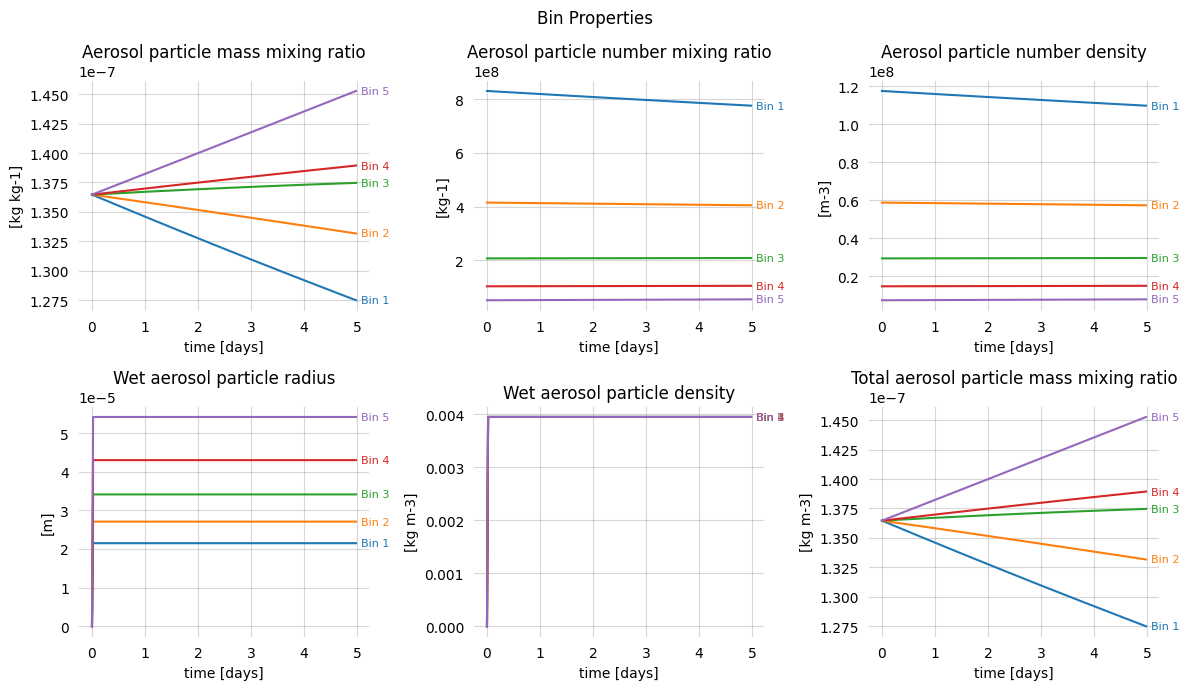

In [8]:
variables = [
    'mass_mixing_ratio', 'number_mixing_ratio', 'number_density',
    'wet_particle_radius', 'wet_particle_density', 'total_mass_mixing_ratio'
]

fig, axs = plt.subplots(figsize=(12, 7), nrows=2, ncols=3)

for var, ax in zip(variables, axs.ravel()):
    for bin in ds.bin.values:
        y = ds[var].sel(bin=bin, element="ALUM").isel(vertical_center=0)
        line, = ax.plot(ds.time, y, label=f'Bin {bin}')
        buffer = (ds.time.values[-1] - ds.time.values[-2]) * 4.50
        ax.text(ds.time.values[-1] + buffer, y.values[-1], f'Bin {bin}',
                va='center', ha='left', fontsize=8, color=line.get_color())

    ax.spines[:].set_visible(False)
    ax.grid(alpha=0.5)
    ax.tick_params(width=0)
    ax.set_xlabel('time [days]')
    ax.set_ylabel(f'[{ds[var].units}]')
    ax.set_title(f'{ds[var].long_name}')

fig.suptitle("Bin Properties")
fig.tight_layout()

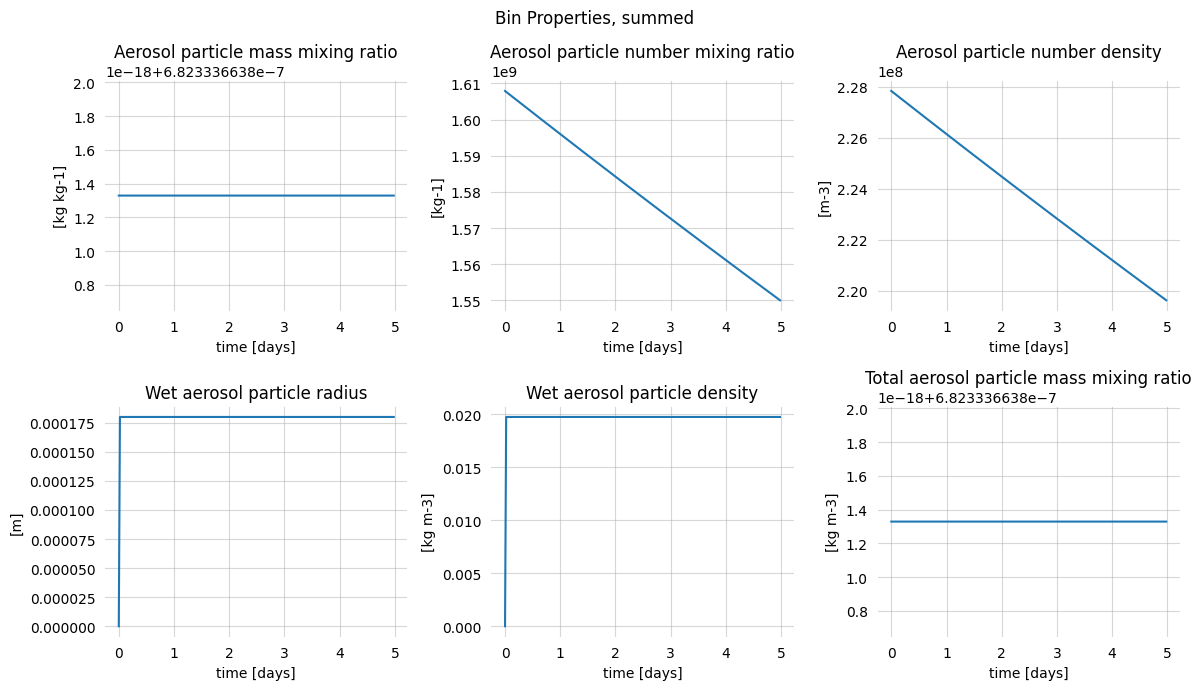

In [9]:
fig, axs = plt.subplots(figsize=(12, 7), nrows=2, ncols=3)

for var, ax in zip(variables, axs.ravel()):
    ax.plot(ds.time, ds[var].sum(dim='bin').sel(element="ALUM").isel(vertical_center=0))

    ax.spines[:].set_visible(False)
    ax.grid(alpha=0.5)
    ax.tick_params(width=0)
    ax.set_xlabel('time [days]')
    ax.set_ylabel(f'[{ds[var].units}]')
    ax.set_title(f'{ds[var].long_name}')

fig.suptitle("Bin Properties, summed")
fig.tight_layout()

CARMA also calculates properties for each group. The `group` coordinate uses the group short names.

In [10]:
group_props, group_config = carma.get_group_properties()

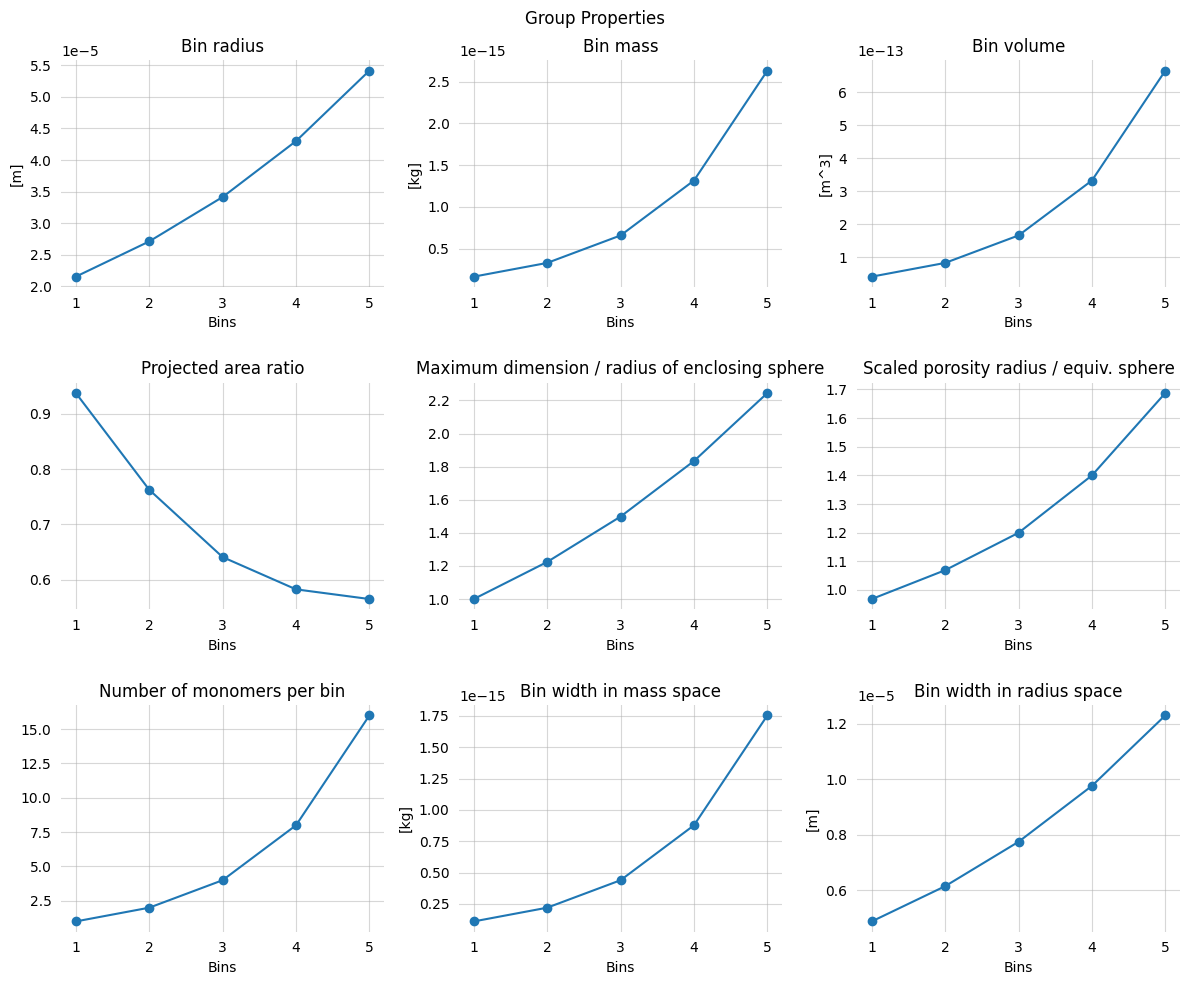

In [11]:
variables = [
    'bin_radius', 'bin_mass', 'bin_volume',
    'projected_area_ratio', 'radius_ratio', 'porosity_ratio',
    'number_of_monomers_per_bin', 'bin_width_mass', 'bin_width'
]

name_to_label = {
    "bin_radius": "Bin radius",
    "bin_width": "Bin width in radius space",
    "bin_mass": "Bin mass",
    "bin_width_mass": "Bin width in mass space",
    "bin_volume": "Bin volume",
    "projected_area_ratio": "Projected area ratio",
    "radius_ratio": "Maximum dimension / radius of enclosing sphere",
    "porosity_ratio": "Scaled porosity radius / equiv. sphere",
    "number_of_monomers_per_bin": "Number of monomers per bin"
}

fig, axs = plt.subplots(figsize=(12, 10), nrows=3, ncols=3)

for var, ax in zip(variables, axs.ravel()):
    values = group_props[var].sel(group="PRALUM")
    ax.plot(values.bin, values, marker='o')

    ax.spines[:].set_visible(False)
    ax.grid(alpha=0.5)
    ax.tick_params(width=0)
    ax.set_xlabel('Bins')
    ax.set_xticks(values.bin)
    if values.units != "-":
        ax.set_ylabel(f'[{values.units}]')
    ax.set_title(name_to_label[var])

fig.suptitle("Group Properties")
fig.tight_layout()

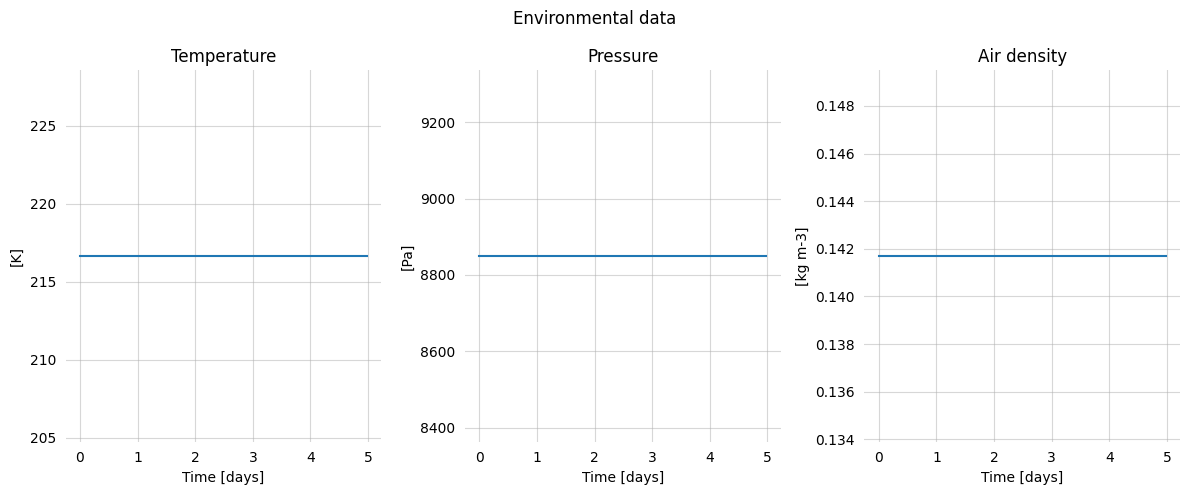

In [12]:
fig, axs = plt.subplots(figsize=(12, 5), nrows=1, ncols=3)

for var, ax in zip(['temperature', 'pressure', 'air_density'], axs.ravel()):
    ax.plot(ds.time, ds[var].isel(vertical_center=0))
    ax.spines[:].set_visible(False)
    ax.grid(alpha=0.5)
    ax.tick_params(width=0)
    ax.set_xlabel('Time [days]')
    ax.set_ylabel(f'[{ds[var].units}]')
    ax.set_title(f'{ds[var].long_name}')

fig.suptitle("Environmental data")
fig.tight_layout()